# Heart Disease Prediction using Machine Learning
## Author: Subhankar Mondal

# Business Problem:

Heart disease is one of the leading causes of death worldwide.

The objective of this project is to build a machine learning
model capable of predicting whether a patient is likely to
have heart disease based on clinical attributes.

This solution can assist healthcare professionals in
early risk assessment and decision-making.


In [1]:
# Import Libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# Load Dataset

df = pd.read_csv(r"D:\Data Analytics Project\heart.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Data Overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# Statistical Summary
print(f'Statistical Summary of the Data:\n{df.describe().T}\n')

Statistical Summary of the Data:
          count        mean        std    min    25%    50%    75%    max
age       303.0   54.366337   9.082101   29.0   47.5   55.0   61.0   77.0
sex       303.0    0.683168   0.466011    0.0    0.0    1.0    1.0    1.0
cp        303.0    0.966997   1.032052    0.0    0.0    1.0    2.0    3.0
trestbps  303.0  131.623762  17.538143   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.264026  51.830751  126.0  211.0  240.0  274.5  564.0
fbs       303.0    0.148515   0.356198    0.0    0.0    0.0    0.0    1.0
restecg   303.0    0.528053   0.525860    0.0    0.0    1.0    1.0    2.0
thalach   303.0  149.646865  22.905161   71.0  133.5  153.0  166.0  202.0
exang     303.0    0.326733   0.469794    0.0    0.0    0.0    1.0    1.0
oldpeak   303.0    1.039604   1.161075    0.0    0.0    0.8    1.6    6.2
slope     303.0    1.399340   0.616226    0.0    1.0    1.0    2.0    2.0
ca        303.0    0.729373   1.022606    0.0    0.0    0.0    1.0    4.0
thal 

In [8]:
# Missing Value Analysis

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [9]:
# Duplicate Check

print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removal:", df.shape)


Duplicate Rows: 1
Shape After Removal: (302, 14)


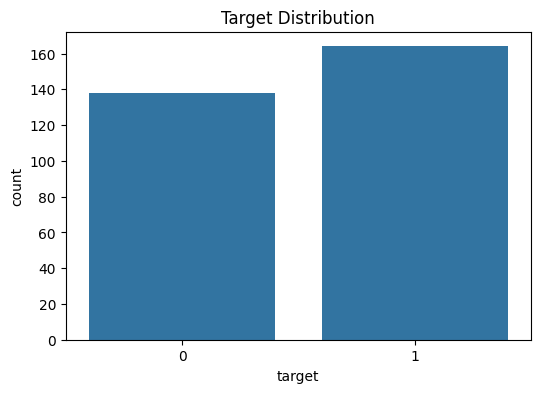

In [ ]:
# Exploratory Data Analysis


# Target Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Target Distribution")
plt.show()

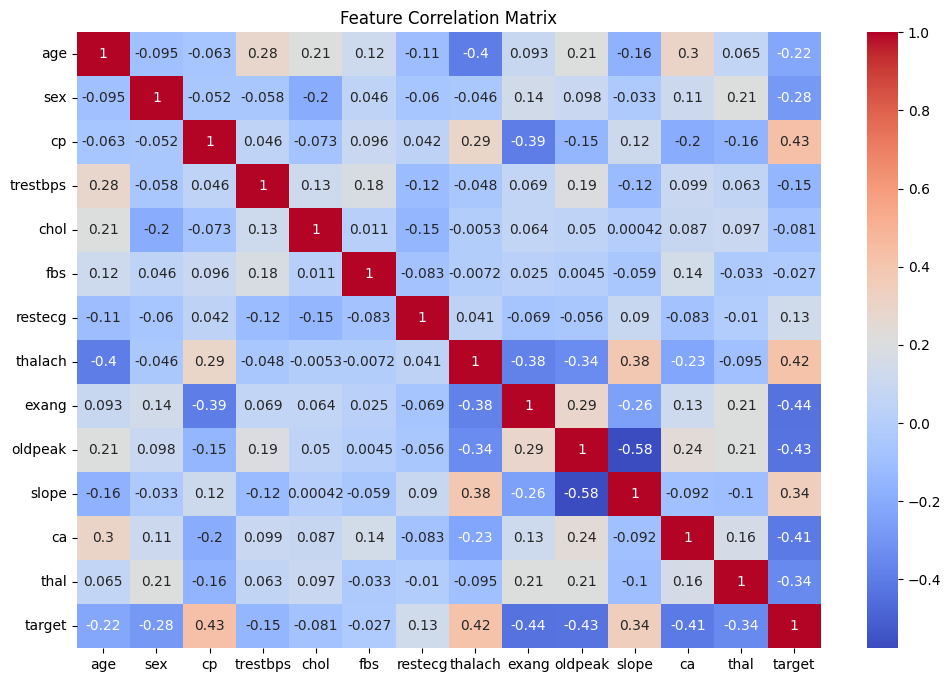

In [11]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

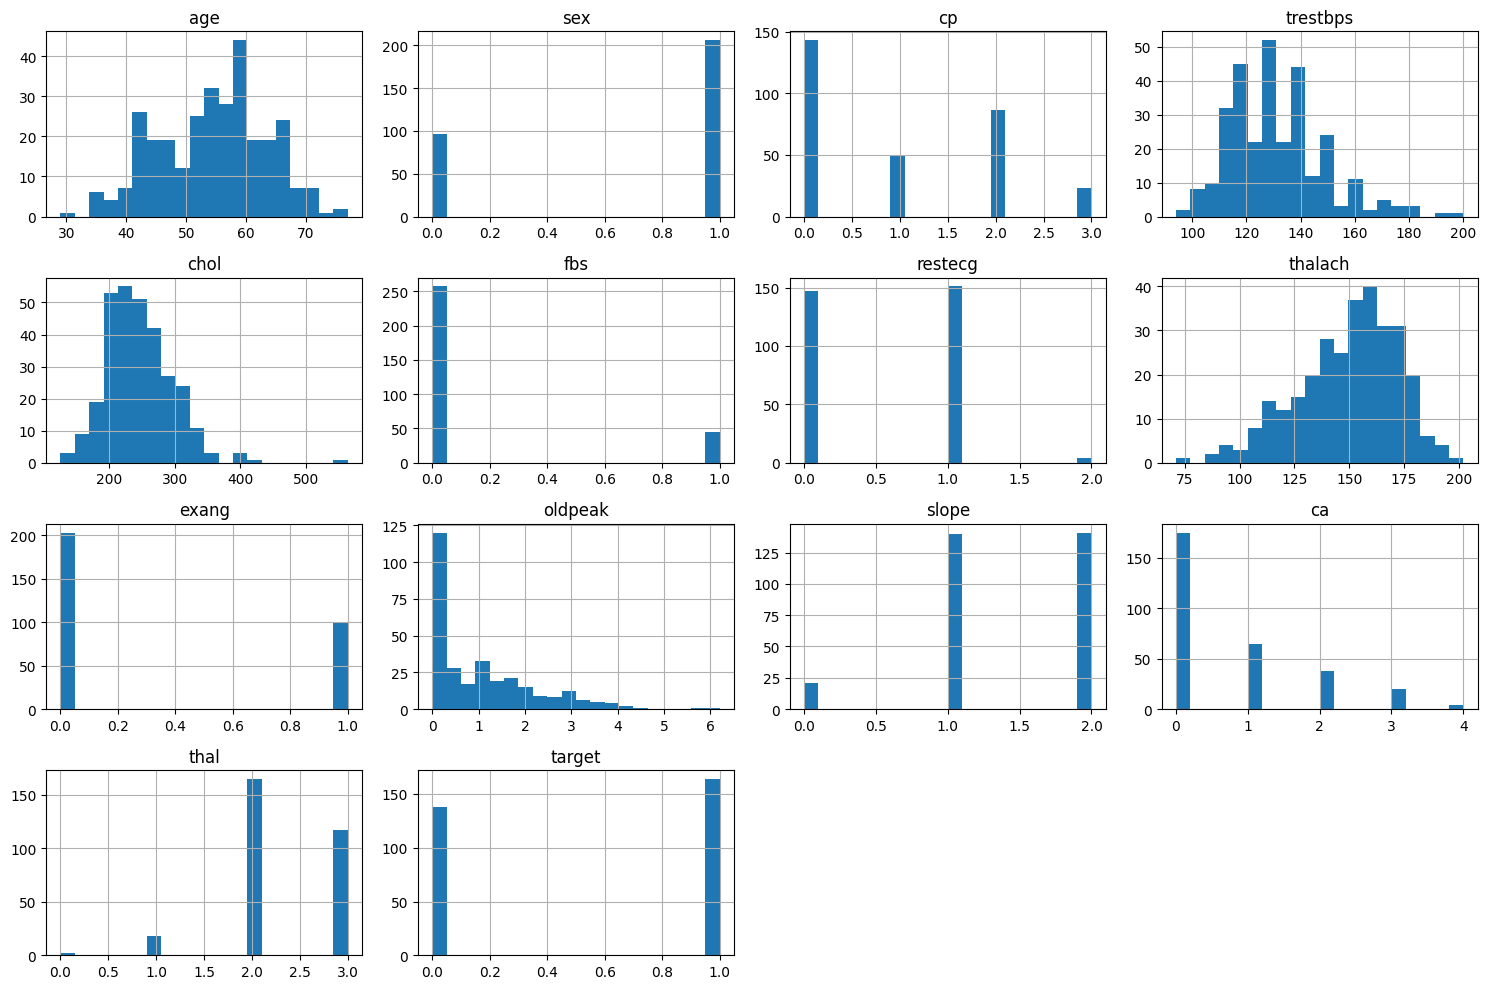

In [12]:
# Feature Distribution

df.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

In [13]:
# Feature Engineering Section

X = df.drop('target', axis=1)
y = df['target']

In [14]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (241, 13)
Testing Shape: (61, 13)


In [15]:
# Model Building

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
# Predictions

y_pred = dt_model.predict(X_test)

In [17]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 72.13 %


In [18]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.61      0.67        28
           1       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61



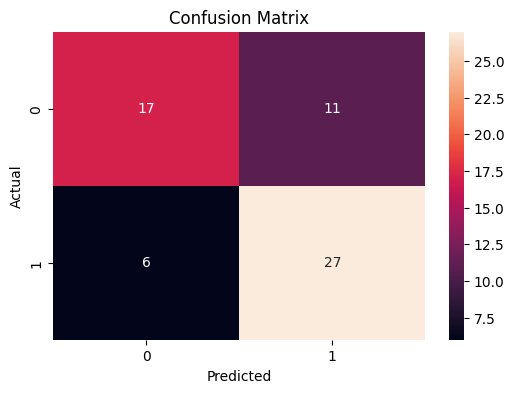

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

params = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [21]:
# Final Model

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print(
    "Final Accuracy:",
    accuracy_score(y_test,y_pred)
)

Final Accuracy: 0.8360655737704918


In [22]:
# Feature Importance

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,cp,0.317029
12,thal,0.172276
9,oldpeak,0.138730
0,age,0.081583
11,ca,0.079756
7,thalach,0.072761
4,chol,0.055168
1,sex,0.026816
8,exang,0.023977
10,slope,0.018593


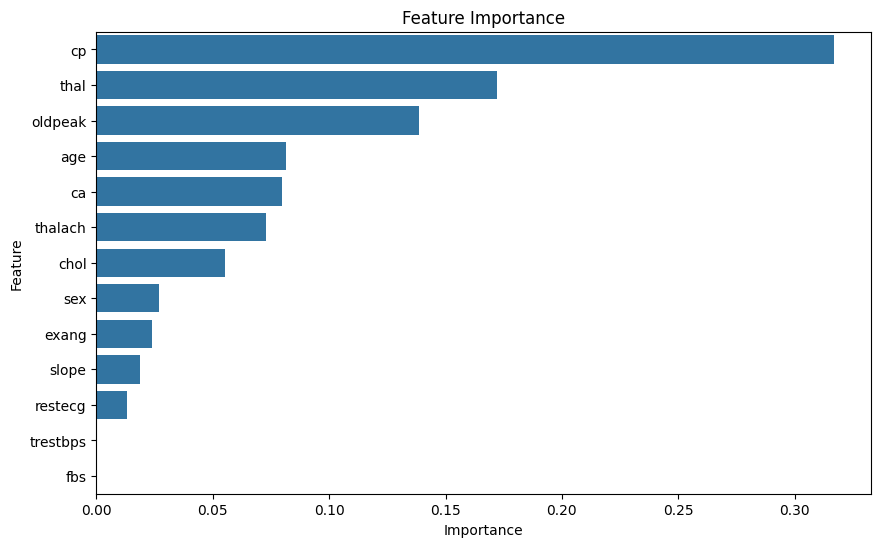

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

## Key Insights

- Chest Pain Type is a strong predictor.
- Maximum Heart Rate contributes significantly.
- ST Depression is highly associated with heart disease risk.